<a href="https://colab.research.google.com/github/aclaire10/Datasci-112-Final-Project/blob/main/DATASCI_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import geopandas as gpd

lines = gpd.read_file('transmission_lines.geojson')

# Check what VOLT_CLASS values actually exist
print(lines['VOLT_CLASS'].value_counts())

VOLT_CLASS
100-161          44665
UNDER 100        30348
NOT AVAILABLE     8822
220-287           7305
345               2602
500                815
735 AND ABOVE       46
DC                  14
Unknown              1
SUB 100              1
Name: count, dtype: int64


In [ ]:
# =============================================================
# STEP 1: filter to only include high-voltage lines
# =============================================================

hv_classes = ['345', '500', '735 AND ABOVE', 'DC']  # DC lines are also high-voltage bulk power
hv_lines = lines[lines['VOLT_CLASS'].isin(hv_classes)].copy()
print(f"Filtered: {len(hv_lines)} high-voltage segments out of {len(lines)} total")

# =============================================================
# STEP 2: map out line segments to their counties after some processing
# =============================================================

import geopandas as gpd

counties = gpd.read_file('cb_2024_us_county_500k.shp')  # adjust path if needed

# Reproject both to Albers Equal Area (meters) so length calculations are accurate
hv_lines = hv_lines.to_crs(epsg=5070)
counties = counties.to_crs(epsg=5070)

# Clip lines to county boundaries — this splits lines at county borders
# so each piece belongs to exactly one county
clipped = gpd.overlay(hv_lines, counties[['GEOID', 'NAME', 'STUSPS', 'ALAND', 'geometry']],
                       how='intersection')
print(f"Clipped segments: {len(clipped)}")

# =============================================================
# STEP 3: find total transmission line for each county after normalizing to county size
# =============================================================

# Calculate length of each clipped segment in km
clipped['length_km'] = clipped.geometry.length / 1000

# Sum total HV line km per county
county_hv = clipped.groupby('GEOID')['length_km'].sum().reset_index()
county_hv.columns = ['GEOID', 'hv_line_km']

# Merge county land area (ALAND is in square meters)
county_area = counties[['GEOID', 'ALAND']].copy()
county_area['land_area_sqkm'] = county_area['ALAND'] / 1e6

county_hv = county_hv.merge(county_area[['GEOID', 'land_area_sqkm']], on='GEOID', how='left')

# Normalize: km of HV line per 1,000 sq km of land area
county_hv['hv_line_km_per_1000sqkm'] = county_hv['hv_line_km'] / county_hv['land_area_sqkm'] * 1000

# Now create full county table — counties with NO HV lines get 0
all_counties = counties[['GEOID']].copy()
county_hv_full = all_counties.merge(county_hv[['GEOID', 'hv_line_km', 'hv_line_km_per_1000sqkm']],
                                      on='GEOID', how='left')
county_hv_full = county_hv_full.fillna(0)

print(f"\nCounties with HV lines: {(county_hv_full['hv_line_km'] > 0).sum()}")
print(f"Counties without HV lines: {(county_hv_full['hv_line_km'] == 0).sum()}")
print(f"\nhv_line_km summary:")
print(county_hv_full['hv_line_km'].describe())

# =============================================================
# STEP 4: join to existing dataset on all the different features
# =============================================================

import pandas as pd

df = pd.read_csv('datasci112_final_cleaned_with_business_tax_proxy.csv')

# county_fips needs to be string with zero-padding to match GEOID
df['county_fips'] = df['county_fips'].astype(str).str.zfill(5)
county_hv_full['GEOID'] = county_hv_full['GEOID'].astype(str).str.zfill(5)

# Merge
df = df.merge(county_hv_full[['GEOID', 'hv_line_km', 'hv_line_km_per_1000sqkm']],
              left_on='county_fips', right_on='GEOID', how='left')
df = df.drop(columns=['GEOID'])
df[['hv_line_km', 'hv_line_km_per_1000sqkm']] = df[['hv_line_km', 'hv_line_km_per_1000sqkm']].fillna(0)

print(f"\nFinal dataset shape: {df.shape}")
print(f"New columns added: hv_line_km, hv_line_km_per_1000sqkm")
print(df[['county_name', 'state_name', 'hv_line_km', 'hv_line_km_per_1000sqkm']].sort_values('hv_line_km', ascending=False).head(10))

# Save the updated dataset
df.to_csv('datasci112_final_with_transmission.csv', index=False)
print("\nSaved to datasci112_final_with_transmission.csv")

Filtered: 3477 high-voltage segments out of 94619 total
Clipped segments: 7346

Counties with HV lines: 1819
Counties without HV lines: 1416

hv_line_km summary:
count    3235.000000
mean       48.927428
std        98.145674
min         0.000000
25%         0.000000
50%        15.548160
75%        60.495731
max      2289.864298
Name: hv_line_km, dtype: float64

Final dataset shape: (3144, 29)
New columns added: hv_line_km, hv_line_km_per_1000sqkm
         county_name  state_name   hv_line_km  hv_line_km_per_1000sqkm
1120  San Bernardino  California  2289.864298                44.055922
976         Coconino     Arizona  1517.981279                31.482852
32          Maricopa     Arizona  1253.468003                52.593556
790            Clark      Nevada  1245.077630                60.915839
322      Los Angeles  California   994.650844                94.584447
304             Will    Illinois   939.967617               434.182926
88          San Juan  New Mexico   867.759552       

In [ ]:
df.head()

,county_fips,county_name,state_fips,state_abbrev,state_name,ALAND,land_area_sqkm,population,pop_density_per_sqkm,dc_total,...,gross_receipts_tax_min,gross_receipts_tax_max,gross_receipts_tax_proxy,tax_regime,state_business_tax_proxy_rate,state_business_tax_proxy_rate_standardized,log_dc_per_100k_pop,log_dc_per_1000_sqkm,hv_line_km,hv_line_km_per_1000sqkm
0,01069,Houston,1,AL,Alabama,1501742250,1501.742250,109366.0,72.826079,0,...,0.0000,0.0000,0.00000,corporate_income_tax_only,0.06500,-0.347662,0.0,0.0,15.764117,10.497219
1,01023,Choctaw,1,AL,Alabama,2365900084,2365.900084,12052.0,5.094044,0,...,0.0000,0.0000,0.00000,corporate_income_tax_only,0.06500,-0.347662,0.0,0.0,0.000000,0.000000
2,01113,Russell,1,AL,Alabama,1660653961,1660.653961,58837.0,35.430018,0,...,0.0000,0.0000,0.00000,corporate_income_tax_only,0.06500,-0.347662,0.0,0.0,0.000000,0.000000
3,10005,Sussex,10,DE,Delaware,2424590442,2424.590442,271134.0,111.826721,0,...,0.0945,1.9914,1.04295,corporate_income_tax_plus_gross_receipts_tax,1.12995,3.891976,0.0,0.0,0.000000,0.000000
4,01071,Jackson,1,AL,Alabama,2792044612,2792.044612,53780.0,19.261870,0,...,0.0000,0.0000,0.00000,corporate_income_tax_only,0.06500,-0.347662,0.0,0.0,198.957464,71.258698


**HISTORICAL DATA CENTER REGRESSION, ML MODEL, FACTOR ANALYSIS**

In [ ]:
# =============================================================
# MODEL 1: use the historical OSM/data center data to determine which factors correlate with HISTORICAL data center development
# =============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('datasci112_final_with_transmission.csv')

# Binary target: does this county have any data center?
df['has_dc'] = (df['dc_total'] > 0).astype(int)

# Features
features = ['electricity_price', 'renewable_share',
            'state_business_tax_proxy_rate', 'pop_density_per_sqkm',
            'hv_line_km_per_1000sqkm']

X = df[features]
y = df['has_dc']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_const = sm.add_constant(X_scaled)

# Logit regression
logit_model = sm.Logit(y, X_const).fit()
print("=" * 60)
print("MODEL 1: HISTORICAL DC LOCATIONS (5 features)")
print("=" * 60)
print(logit_model.summary())
print(f"\nPseudo R²: {logit_model.prsquared:.5f}")

Optimization terminated successfully.
         Current function value: 0.068202
         Iterations 9
MODEL 1: HISTORICAL DC LOCATIONS (5 features)
                           Logit Regression Results                           
Dep. Variable:                 has_dc   No. Observations:                 3144
Model:                          Logit   Df Residuals:                     3138
Method:                           MLE   Df Model:                            5
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                 0.07386
Time:                        21:03:55   Log-Likelihood:                -214.43
converged:                       True   LL-Null:                       -231.53
Covariance Type:            nonrobust   LLR p-value:                 2.170e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.4977      0.178    -25.203      0.000      -4

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 5, 'n_estimators': 500}
Best CV average precision: 0.2089


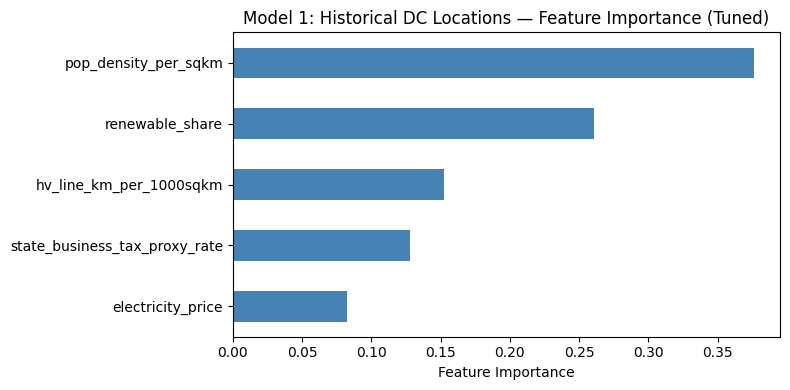


Feature Importances:
--------------------------------------------------
                  electricity_price:  0.0822
                    renewable_share:  0.2609
      state_business_tax_proxy_rate:  0.1282
               pop_density_per_sqkm:  0.3763
            hv_line_km_per_1000sqkm:  0.1524


In [ ]:
# =============================================================
# MODEL 1: Use XGBClassifer to create an ML model trained off of the historical data center data
# =============================================================
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'max_depth': [5, 10, 20],
    'learning_rate': [0.01, 0.1],
    'min_child_weight': [1, 5],
    'n_estimators': [100, 500]
}

neg = (y == 0).sum()
pos = (y == 1).sum()

xgb_base = XGBClassifier(
    scale_pos_weight=neg/pos,
    eval_metric='logloss',
    random_state=42
)

grid_search = GridSearchCV(
    estimator= xgb_base,
    param_grid=param_grid,
    cv=5,
    scoring='average_precision',
    refit=True,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_scaled, y)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV average precision: {grid_search.best_score_:.4f}")

rf_model = grid_search.best_estimator_

imp = pd.Series(rf_model.feature_importances_, index=features).sort_values()
imp.plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.title('Model 1: Historical DC Locations — Feature Importance (Tuned)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("\nFeature Importances:")
print("-" * 50)
for feat in features:
    print(f"{feat:>35s}:  {rf_model.feature_importances_[features.index(feat)]:.4f}")

 **NEW DATA CENTER DATA: REGRESSION & ML MODEL TRAINING**

In [ ]:
# =============================================================
# MODEL 2: Based on NEW DC DATA — all recent data center data (both built & planned, together)
# =============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Load data
dc = pd.read_csv('new_dc_final.csv')
df = pd.read_csv('datasci112_final_with_transmission.csv')

# Fix mismatch and create match keys
dc['county_clean'] = dc['county'].str.strip()
dc.loc[dc['county_clean'] == 'La Porte', 'county_clean'] = 'LaPorte'
dc['match_key'] = dc['county_clean'].str.lower() + '_' + dc['state'].str.strip().str.lower()
df['match_key'] = df['county_name'].str.strip().str.lower() + '_' + df['state_abbrev'].str.strip().str.lower()

# Build dependent variables
all_new_keys = set(dc['match_key'].unique())
df['has_new_dc'] = df['match_key'].isin(all_new_keys).astype(int)
df['has_dc'] = (df['dc_total'] > 0).astype(int)

print(f"Counties with ANY new DC (built + planned): {df['has_new_dc'].sum()}")
print(f"Counties with historical DCs (OSM):         {df['has_dc'].sum()}")

# Standardize features
features = ['electricity_price', 'renewable_share',
            'state_business_tax_proxy_rate', 'pop_density_per_sqkm',
            'hv_line_km_per_1000sqkm']

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_const = sm.add_constant(X_scaled)

# Run both logits
logit_hist = sm.Logit(df['has_dc'], X_const).fit(disp=0)
logit_new = sm.Logit(df['has_new_dc'], X_const).fit(disp=0)

# Print summaries
print("\n" + "=" * 60)
print("MODEL 1: HISTORICAL DC LOCATIONS")
print("=" * 60)
print(logit_hist.summary())

print("\n" + "=" * 60)
print("MODEL 2: NEW DC LOCATIONS (BUILT + PLANNED)")
print("=" * 60)
print(logit_new.summary())

# =============================================================
# logit coefficient comparison table comparing the historical logit with the new logit
# =============================================================
print("\n" + "=" * 70)
print("LOGIT COEFFICIENT COMPARISON: HISTORICAL vs NEW")
print("=" * 70)
feature_names = ['const'] + features
print(f"\n{'Feature':>35s} | {'Historical':>12s} | {'New':>12s}")
print("-" * 65)
for i, feat in enumerate(feature_names):
    h_coef = logit_hist.params.iloc[i]
    h_pval = logit_hist.pvalues.iloc[i]
    n_coef = logit_new.params.iloc[i]
    n_pval = logit_new.pvalues.iloc[i]
    h_star = '***' if h_pval<0.001 else '**' if h_pval<0.01 else '*' if h_pval<0.05 else ''
    n_star = '***' if n_pval<0.001 else '**' if n_pval<0.01 else '*' if n_pval<0.05 else ''
    print(f"{feat:>35s} | {h_coef:>8.4f}{h_star:>4s} | {n_coef:>8.4f}{n_star:>4s}")

print(f"\n{'Pseudo R²':>35s} | {logit_hist.prsquared:>12.5f} | {logit_new.prsquared:>12.5f}")
print(f"{'N (positive class)':>35s} | {df['has_dc'].sum():>12d} | {df['has_new_dc'].sum():>12d}")

Counties with ANY new DC (built + planned): 65
Counties with historical DCs (OSM):         44

MODEL 1: HISTORICAL DC LOCATIONS
                           Logit Regression Results                           
Dep. Variable:                 has_dc   No. Observations:                 3144
Model:                          Logit   Df Residuals:                     3138
Method:                           MLE   Df Model:                            5
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                 0.07386
Time:                        21:04:41   Log-Likelihood:                -214.43
converged:                       True   LL-Null:                       -231.53
Covariance Type:            nonrobust   LLR p-value:                 2.170e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.4977      0.178    -25.203      0.000      -4.847      -4.148
x1 

In [ ]:
# =============================================================
# New trained RF model off of the new data center data, comparing HISTORICAL model vs NEW model
# =============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# --- Logit Coefficients (skip constant) ---
coef_data = pd.DataFrame({
    'Historical': logit_hist.params.iloc[1:].values,
    'New': logit_new.params.iloc[1:].values,
}, index=features)

# --- GridSearchCV for NEW model only, reuse historical ---
param_grid_rf = {
    'max_features': ['sqrt', None],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gs_new = GridSearchCV(
    estimator=RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='average_precision',
    refit=True,
    n_jobs=-1
)
gs_new.fit(X_scaled, df['has_new_dc'])
rf_model_new = gs_new.best_estimator_
print(f"New: best params = {gs_new.best_params_}, best CV score = {gs_new.best_score_:.4f}")

tuned_models = {
    'Historical': rf_model,
    'New': rf_model_new
}

imp_data = pd.DataFrame({
    name: model.feature_importances_ for name, model in tuned_models.items()
}, index=features)

# Print importances
print("\nFeature Importance Comparison (Historical XGBoost vs New RF):")
print("-" * 65)
print(f"{'Feature':>35s} | {'Historical':>12s} | {'New':>12s}")
print("-" * 65)
for feat in features:
    print(f"{feat:>35s} | {imp_data.loc[feat,'Historical']:>12.4f} | {imp_data.loc[feat,'New']:>12.4f}")

New: best params = {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}, best CV score = 0.1061

Feature Importance Comparison (Historical XGBoost vs New RF):
-----------------------------------------------------------------
                            Feature |   Historical |          New
-----------------------------------------------------------------
                  electricity_price |       0.0822 |       0.1096
                    renewable_share |       0.2609 |       0.0918
      state_business_tax_proxy_rate |       0.1282 |       0.1125
               pop_density_per_sqkm |       0.3763 |       0.4358
            hv_line_km_per_1000sqkm |       0.1524 |       0.2503


**PLOTS**

In [ ]:
# =============================================================
# PLOT 1: LOGIT COEFFICIENTS BY MODEL (Plotly)
# =============================================================
import plotly.graph_objects as go

feature_labels = ['Electricity<br>Price', 'Renewable<br>Share', 'Business<br>Tax Rate',
                  'Population<br>Density', 'HV Transmission<br>Lines']

hist_coefs = coef_data['Historical'].values
new_coefs = coef_data['New'].values

fig1 = go.Figure()

fig1.add_trace(go.Bar(
    name='Historical',
    x=feature_labels,
    y=hist_coefs,
    marker=dict(
        color='rgba(55, 83, 109, 0.85)',
        line=dict(color='rgba(55, 83, 109, 1)', width=1.5)
    ),
    text=[f'{v:+.3f}' for v in hist_coefs],
    textposition='outside',
    textfont=dict(size=11, color='rgba(55, 83, 109, 1)', family='DM Sans')
))

fig1.add_trace(go.Bar(
    name='New',
    x=feature_labels,
    y=new_coefs,
    marker=dict(
        color='rgba(235, 134, 52, 0.85)',
        line=dict(color='rgba(235, 134, 52, 1)', width=1.5)
    ),
    text=[f'{v:+.3f}' for v in new_coefs],
    textposition='outside',
    textfont=dict(size=11, color='rgba(235, 134, 52, 1)', family='DM Sans')
))

fig1.add_hline(y=0, line_width=1.5, line_color='rgba(0,0,0,0.3)')

fig1.update_layout(
    title=dict(
        text='<b>Logit Regression Coefficients</b>',
        font=dict(size=22, family='DM Sans', color='#1a1a2e'),
        x=0.5, xanchor='center',
        y=0.95
    ),
    barmode='group',
    bargap=0.25,
    bargroupgap=0.08,
    plot_bgcolor='rgba(250, 248, 246, 1)',
    paper_bgcolor='rgba(250, 248, 246, 1)',
    font=dict(family='DM Sans', size=13),
    xaxis=dict(
        tickfont=dict(size=12, family='DM Sans', color='#333'),
        showgrid=False,
        linecolor='rgba(0,0,0,0.1)'
    ),
    yaxis=dict(
        title=dict(text='Standardized Coefficient', font=dict(size=13, family='DM Sans', color='#555')),
        gridcolor='rgba(0,0,0,0.06)',
        gridwidth=1,
        zeroline=False,
        tickfont=dict(size=11, family='DM Sans', color='#555'),
        range=[-0.55, 0.65]
    ),
    legend=dict(
        orientation='h',
        yanchor='top', y=-0.15,
        xanchor='center', x=0.5,
        font=dict(size=12, family='DM Sans'),
        bgcolor='rgba(0,0,0,0)',
        borderwidth=0
    ),
    margin=dict(l=60, r=40, t=80, b=100),
    width=750,
    height=500,
)

fig1.show()

In [ ]:
# =============================================================
# PLOT 2: XGBoost FEATURE IMPORTANCE (Plotly)
# =============================================================
import plotly.graph_objects as go

feature_labels = ['Electricity<br>Price', 'Renewable<br>Share', 'Business<br>Tax Rate',
                  'Population<br>Density', 'HV Transmission<br>Lines']

hist_imp = imp_data['Historical'].values
new_imp = imp_data['New'].values

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    name='Historical',
    x=feature_labels,
    y=hist_imp,
    marker=dict(
        color='rgba(55, 83, 109, 0.85)',
        line=dict(color='rgba(55, 83, 109, 1)', width=1.5)
    ),
    text=[f'{v:.3f}' for v in hist_imp],
    textposition='outside',
    textfont=dict(size=11, color='rgba(55, 83, 109, 1)', family='DM Sans')
))

fig2.add_trace(go.Bar(
    name='New',
    x=feature_labels,
    y=new_imp,
    marker=dict(
        color='rgba(235, 134, 52, 0.85)',
        line=dict(color='rgba(235, 134, 52, 1)', width=1.5)
    ),
    text=[f'{v:.3f}' for v in new_imp],
    textposition='outside',
    textfont=dict(size=11, color='rgba(235, 134, 52, 1)', family='DM Sans')
))

fig2.update_layout(
    title=dict(
        text='<b>XGBoost Feature Importance</b>',
        font=dict(size=22, family='DM Sans', color='#1a1a2e'),
        x=0.5, xanchor='center',
        y=0.95
    ),
    barmode='group',
    bargap=0.25,
    bargroupgap=0.08,
    plot_bgcolor='rgba(250, 248, 246, 1)',
    paper_bgcolor='rgba(250, 248, 246, 1)',
    font=dict(family='DM Sans', size=13),
    xaxis=dict(
        tickfont=dict(size=12, family='DM Sans', color='#333'),
        showgrid=False,
        linecolor='rgba(0,0,0,0.1)'
    ),
    yaxis=dict(
        title=dict(text='Feature Importance', font=dict(size=13, family='DM Sans', color='#555')),
        gridcolor='rgba(0,0,0,0.06)',
        gridwidth=1,
        zeroline=False,
        tickfont=dict(size=11, family='DM Sans', color='#555'),
        range=[0, 0.58]
    ),
    legend=dict(
        orientation='h',
        yanchor='top', y=-0.15,
        xanchor='center', x=0.5,
        font=dict(size=12, family='DM Sans'),
        bgcolor='rgba(0,0,0,0)',
        borderwidth=0
    ),
    margin=dict(l=60, r=40, t=80, b=100),
    width=750,
    height=500
)

fig2.show()

In [ ]:
# =============================================================
# using historical data model to predict the top 30 counties for new DC development off of that old, trained data
# =============================================================

# Create match key if it doesn't exist yet
df['match_key'] = df['county_name'].str.strip().str.lower() + '_' + df['state_abbrev'].str.strip().str.lower()

# Get predicted probabilities from historical model
df['hist_dc_probability'] = rf_model.predict_proba(X_scaled)[:, 1]

# Only look at counties that DON'T already have historical DCs
no_dc = df[df['has_dc'] == 0].copy()
emerging_hist = no_dc.sort_values('hist_dc_probability', ascending=False)

# Flag which ones actually got new DCs
all_new_keys = set(dc['match_key'].unique())
emerging_hist['actually_got_new_dc'] = emerging_hist['match_key'].isin(all_new_keys).map({True: '✓', False: ''})

print("=" * 90)
print("TOP 30 PREDICTED COUNTIES — HISTORICAL MODEL")
print("(Counties without existing DCs, ranked by historical model probability)")
print("=" * 90)
print(emerging_hist[['county_name', 'state_name', 'hist_dc_probability',
                     'electricity_price', 'pop_density_per_sqkm',
                     'hv_line_km_per_1000sqkm', 'actually_got_new_dc']].head(30).to_string(index=False))

top30_hist = emerging_hist.head(30)
hit_count_hist = (top30_hist['actually_got_new_dc'] == '✓').sum()
print(f"\nOf the top 30, {hit_count_hist} actually received new DC development")
print(f"Hit rate: {hit_count_hist/30:.1%}")

TOP 30 PREDICTED COUNTIES — HISTORICAL MODEL
(Counties without existing DCs, ranked by historical model probability)
         county_name           state_name  hist_dc_probability  electricity_price  pop_density_per_sqkm  hv_line_km_per_1000sqkm actually_got_new_dc
               Clark           Washington             0.966700           6.609028            323.913204                20.134738                    
              Denver             Colorado             0.959801           8.622039           1838.820394                 0.000000                    
             Alameda           California             0.944991          21.527795            863.377453                36.037163                    
              Harris                Texas             0.940133           6.121500           1132.850876               133.007615                    
District of Columbia District of Columbia             0.935169          10.804457           4435.743684                 0.000000          

In [12]:
# =============================================================
# NEW model trained off of the new data to predict the top 30 counties for new DC development
# then, comparing the two lists
# =============================================================

# Get predicted probabilities from new model
df['new_dc_probability'] = rf_model_new.predict_proba(X_scaled)[:, 1]

# Only look at counties that DON'T already have new DCs
no_new_dc = df[df['has_new_dc'] == 0].copy()
emerging_new = no_new_dc.sort_values('new_dc_probability', ascending=False)

# Flag which ones have historical DCs (interesting to see overlap)
emerging_new['has_historical_dc'] = emerging_new['has_dc'].map({1: '✓', 0: ''})

print("=" * 90)
print("TOP 30 PREDICTED COUNTIES — NEW MODEL (BUILT + PLANNED)")
print("(Counties without new DCs, ranked by new model probability)")
print("=" * 90)
print(emerging_new[['county_name', 'state_name', 'new_dc_probability',
                    'electricity_price', 'pop_density_per_sqkm',
                    'hv_line_km_per_1000sqkm', 'has_historical_dc']].head(30).to_string(index=False))

# Compare the two top-30 lists
top30_new = emerging_new.head(30)
hist_set = set(top30_hist['match_key'])
new_set = set(top30_new['match_key'])

overlap = hist_set & new_set
only_hist = hist_set - new_set
only_new = new_set - hist_set

print(f"\n{'='*60}")
print(f"COMPARISON OF TOP 30 LISTS")
print(f"{'='*60}")
print(f"Counties in BOTH top 30 lists:        {len(overlap)}")
print(f"Counties ONLY in historical top 30:   {len(only_hist)}")
print(f"Counties ONLY in new model top 30:    {len(only_new)}")

TOP 30 PREDICTED COUNTIES — NEW MODEL (BUILT + PLANNED)
(Counties without new DCs, ranked by new model probability)
county_name state_name  new_dc_probability  electricity_price  pop_density_per_sqkm  hv_line_km_per_1000sqkm has_historical_dc
   Paulding    Georgia            0.822008           7.211297            233.043242               127.770409                  
      Henry    Georgia            0.812899           7.211297            314.149079                56.428695                  
    Kenosha  Wisconsin            0.804066           8.538536            239.692273               130.794538                  
      Brown  Wisconsin            0.802629           8.538536            199.506694                59.072150                  
    Fayette    Georgia            0.781000           7.211297            248.101819                71.676995                  
     Denton      Texas            0.755665           6.121500            459.201136               118.898326              

## Load Spatial Data and Merge Transmission Data


In [13]:
#merge the two dataframes on GEOID and filter out Alaska and Hawaii.

counties['GEOID'] = counties['GEOID'].astype(str).str.zfill(5)
county_hv_full['GEOID'] = county_hv_full['GEOID'].astype(str).str.zfill(5)

# 1. Merge counties with hv_line data
counties_with_hv = counties.merge(county_hv_full[['GEOID', 'hv_line_km', 'hv_line_km_per_1000sqkm']],
                                  on='GEOID', how='left')

# Fill any NaN values from counties without HV lines with 0
counties_with_hv[['hv_line_km', 'hv_line_km_per_1000sqkm']] = counties_with_hv[['hv_line_km', 'hv_line_km_per_1000sqkm']].fillna(0)

# 2. Filter for contiguous US states
contiguous_us_counties = counties_with_hv[~counties_with_hv['STUSPS'].isin(['AK', 'HI'])]

print(f"Shape of counties_with_hv: {counties_with_hv.shape}")
print(f"Shape of contiguous_us_counties (excluding AK, HI): {contiguous_us_counties.shape}")
print("First 5 rows of contiguous_us_counties with new columns:")
print(contiguous_us_counties[['NAME', 'STUSPS', 'hv_line_km', 'hv_line_km_per_1000sqkm']].head())

Shape of counties_with_hv: (3235, 15)
Shape of contiguous_us_counties (excluding AK, HI): (3200, 15)
First 5 rows of contiguous_us_counties with new columns:
      NAME STUSPS  hv_line_km  hv_line_km_per_1000sqkm
0  Houston     AL   15.764117                10.497219
1  Choctaw     AL    0.000000                 0.000000
2  Russell     AL    0.000000                 0.000000
3   Sussex     DE    0.000000                 0.000000
4  Jackson     AL  198.957464                71.258698


In [14]:
#extract geometries of top 30 predicted counties

top30_new_copy = top30_new.copy()
top30_new_copy['county_fips'] = top30_new_copy['county_fips'].astype(str)

# Create a temporary DataFrame with GEOID as string for merging
# This avoids modifying the original contiguous_us_counties and the SettingWithCopyWarning
temp_contiguous_us_counties = contiguous_us_counties[['GEOID', 'geometry']].copy()
temp_contiguous_us_counties['GEOID'] = temp_contiguous_us_counties['GEOID'].astype(str)

top30_new_geo = top30_new_copy.merge(temp_contiguous_us_counties,
                                 left_on='county_fips', right_on='GEOID', how='left')

print(f"Shape of top30_new_geo: {top30_new_geo.shape}")
print("Columns in top30_new_geo:")
print(top30_new_geo.columns)
print("First 5 rows of top30_new_geo with geometry column:")
print(top30_new_geo[['county_name', 'state_name', 'new_dc_probability', 'geometry']].head())

Shape of top30_new_geo: (30, 37)
Columns in top30_new_geo:
Index(['county_fips', 'county_name', 'state_fips', 'state_abbrev',
       'state_name', 'ALAND', 'land_area_sqkm', 'population',
       'pop_density_per_sqkm', 'dc_total', 'dc_hyper', 'dc_colo',
       'electricity_price', 'renewable_share', 'corporate_tax_rate',
       'dc_per_100k_pop', 'dc_per_1000_sqkm', 'log_population',
       'corporate_tax_rate_filled', 'gross_receipts_tax_min',
       'gross_receipts_tax_max', 'gross_receipts_tax_proxy', 'tax_regime',
       'state_business_tax_proxy_rate',
       'state_business_tax_proxy_rate_standardized', 'log_dc_per_100k_pop',
       'log_dc_per_1000_sqkm', 'hv_line_km', 'hv_line_km_per_1000sqkm',
       'match_key', 'has_new_dc', 'has_dc', 'hist_dc_probability',
       'new_dc_probability', 'has_historical_dc', 'GEOID', 'geometry'],
      dtype='object')
First 5 rows of top30_new_geo with geometry column:
  county_name state_name  new_dc_probability  \
0    Paulding    Georgia   

Retraining xgb_model_new (~30s)...
Done.


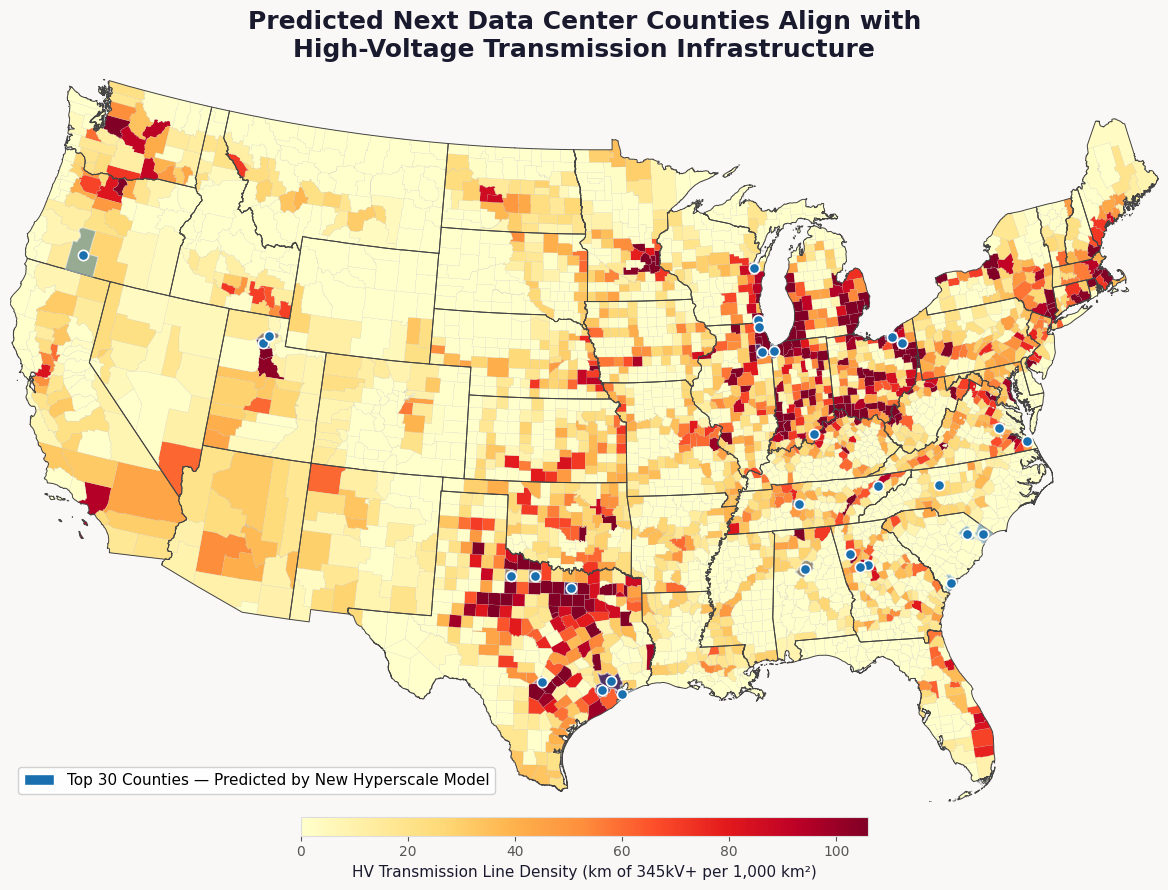

Saved: dc_transmission_map.png


In [15]:
#choropleth map visualizing high-voltage transmission line density and overlaying the top 30 predicted data center locations

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier

# ── Retrain xgb_model_new if not in memory ─────────────────────
if 'xg_model_new' not in dir():
    print("Retraining xgb_model_new (~30s)...")
    xgb_model_new = RandomForestClassifier(
        n_estimators=300, max_depth=20, max_features='sqrt',
        min_samples_split=5, min_samples_leaf=2,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    xgb_model_new.fit(X_scaled, df['has_new_dc'])
    print("Done.")

# ── Predicted probabilities + top-30 ──────────────────────────
df['new_dc_probability'] = xgb_model_new.predict_proba(X_scaled)[:, 1]

top30_new = (df[df['has_new_dc'] == 0]
             .sort_values('new_dc_probability', ascending=False)
             .head(30))

# ── Merge top-30 with county geometry ─────────────────────────
top30_copy = top30_new.copy()
top30_copy['county_fips'] = top30_copy['county_fips'].astype(str).str.zfill(5)

temp = contiguous_us_counties[['GEOID', 'geometry']].copy()
temp['GEOID'] = temp['GEOID'].astype(str).str.zfill(5)

top30_geo = top30_copy.merge(temp, left_on='county_fips', right_on='GEOID', how='left')
top30_gdf = gpd.GeoDataFrame(top30_geo, geometry='geometry', crs=contiguous_us_counties.crs)

# ── Filter to only the 48 contiguous states by FIPS ───────────
excluded = ['02', '15', '60', '66', '69', '72', '78']
base = contiguous_us_counties.copy()
base['statefp'] = base['GEOID'].astype(str).str.zfill(5).str[:2]
base_48 = base[~base['statefp'].isin(excluded)].copy()

top30_gdf['statefp'] = top30_gdf['GEOID'].astype(str).str.zfill(5).str[:2]
top30_48 = top30_gdf[~top30_gdf['statefp'].isin(excluded)].copy()

# ── Reproject to Albers Equal Area ────────────────────────────
base_48   = base_48.to_crs(epsg=5070)
top30_48  = top30_48.to_crs(epsg=5070)

# Derive bounds cleanly from the filtered 48-state data
minx, miny, maxx, maxy = base_48.total_bounds

# Centroids for dot markers
top30_48 = top30_48.copy()
top30_48['centroid'] = top30_48.geometry.centroid

# ── FIGURE ────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(16, 9), facecolor='#faf8f6')
ax.set_facecolor('#faf8f6')
ax.set_axis_off()
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Choropleth: HV transmission density
p95 = base_48['hv_line_km_per_1000sqkm'].quantile(0.95)

base_48.plot(
    ax=ax,
    column='hv_line_km_per_1000sqkm',
    cmap='YlOrRd',
    vmin=0,
    vmax=p95,
    linewidth=0.1,
    edgecolor='#bbbbbb',
    legend=False,
    zorder=1
)

# State outlines
base_48.dissolve(by='STUSPS').boundary.plot(
    ax=ax, color='#444444', linewidth=0.7, zorder=2
)

# Top-30: filled polygons (subtle background)
top30_48.plot(
    ax=ax, color='#1a6faf', edgecolor='white',
    linewidth=0.8, alpha=0.45, zorder=3
)

# Top-30: centroid dots so small counties are always visible
top30_48['centroid'].plot(
    ax=ax, color='#1a6faf', markersize=55,
    edgecolor='white', linewidth=1.2,
    zorder=5
)

# ── Colorbar ──────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap='YlOrRd',
    norm=mcolors.Normalize(vmin=0, vmax=p95)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                    fraction=0.025, pad=0.02, shrink=0.45, aspect=30)
cbar.set_label('HV Transmission Line Density (km of 345kV+ per 1,000 km²)',
               fontsize=11, color='#1a1a2e', fontfamily='sans-serif')
cbar.ax.tick_params(labelsize=10, colors='#555')
cbar.outline.set_edgecolor('#dddddd')

# ── Legend ────────────────────────────────────────────────────
ax.legend(
    handles=[mpatches.Patch(facecolor='#1a6faf', edgecolor='white',
                            label='Top 30 Counties — Predicted by New Hyperscale Model')],
    loc='lower left', fontsize=11, framealpha=0.9, edgecolor='#cccccc'
)

# ── Title ─────────────────────────────────────────────────────
ax.set_title(
    'Predicted Next Data Center Counties Align with\nHigh-Voltage Transmission Infrastructure',
    fontsize=18, fontweight='bold', pad=16,
    fontfamily='sans-serif', color='#1a1a2e'
)

plt.tight_layout()
plt.savefig('dc_transmission_map.png', dpi=200, bbox_inches='tight', facecolor='#faf8f6')
plt.show()
print("Saved: dc_transmission_map.png")

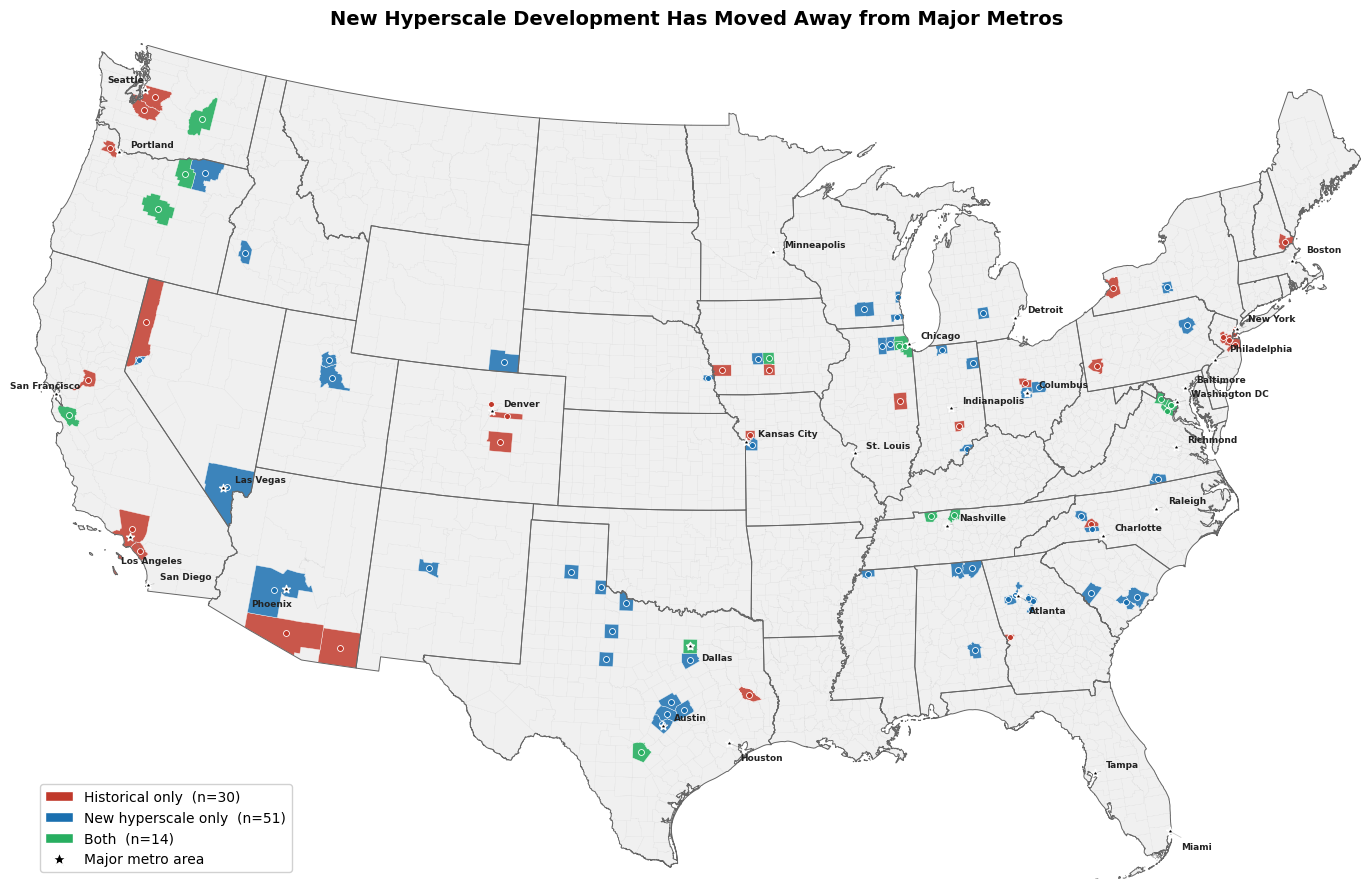

Saved: dc_combined_metros_map.png


In [16]:
#hyperscale development has moved away from major metros

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import geopandas as gpd
import pandas as pd

# ── Major US metros — hardcoded (lat/lon, no file needed) ─────
# These are the 30 largest US metros by population
metros = pd.DataFrame({
    'city': [
        'New York', 'Los Angeles', 'Chicago', 'Dallas', 'Houston',
        'Washington DC', 'Miami', 'Philadelphia', 'Atlanta', 'Phoenix',
        'Boston', 'San Francisco', 'Seattle', 'Detroit', 'Minneapolis',
        'San Diego', 'Tampa', 'Denver', 'Portland', 'St. Louis',
        'Baltimore', 'Charlotte', 'Indianapolis', 'Columbus', 'Austin',
        'Las Vegas', 'Nashville', 'Kansas City', 'Raleigh', 'Richmond'
    ],
    'lat': [
        40.71, 34.05, 41.88, 32.78, 29.76,
        38.91, 25.77, 39.95, 33.75, 33.45,
        42.36, 37.77, 47.61, 42.33, 44.98,
        32.72, 27.95, 39.74, 45.52, 38.63,
        39.29, 35.23, 39.77, 39.96, 30.27,
        36.17, 36.17, 39.10, 35.78, 37.54
    ],
    'lon': [
        -74.01, -118.24, -87.63, -96.80, -95.37,
        -77.04, -80.19, -75.17, -84.39, -112.07,
        -71.06, -122.42, -122.33, -83.05, -93.27,
        -117.16, -82.46, -104.98, -122.68, -90.20,
        -76.61, -80.84, -86.16, -82.99, -97.74,
        -115.14, -86.78, -94.58, -78.64, -77.43
    ]
})

metros_gdf = gpd.GeoDataFrame(
    metros,
    geometry=gpd.points_from_xy(metros['lon'], metros['lat']),
    crs='EPSG:4326'
).to_crs(epsg=5070)

# ── Filter to clean 48-state base ─────────────────────────────
excluded = ['02', '15', '60', '66', '69', '72', '78']
base = contiguous_us_counties.copy()
base['statefp'] = base['GEOID'].astype(str).str.zfill(5).str[:2]
base_48 = base[~base['statefp'].isin(excluded)].to_crs(epsg=5070)

minx, miny, maxx, maxy = base_48.total_bounds

# ── Merge DC flags onto geometry ──────────────────────────────
base_48 = base_48.merge(
    df[['county_fips', 'has_dc', 'has_new_dc']].assign(
        county_fips=df['county_fips'].astype(str).str.zfill(5)
    ),
    left_on='GEOID', right_on='county_fips', how='left'
)
base_48['has_dc']     = base_48['has_dc'].fillna(0).astype(int)
base_48['has_new_dc'] = base_48['has_new_dc'].fillna(0).astype(int)

# ── Classify each county ──────────────────────────────────────
def classify(row):
    if row['has_dc'] == 1 and row['has_new_dc'] == 1:
        return 'overlap'
    elif row['has_dc'] == 1:
        return 'historical'
    elif row['has_new_dc'] == 1:
        return 'new'
    else:
        return 'none'

base_48['category'] = base_48.apply(classify, axis=1)

none_gdf       = base_48[base_48['category'] == 'none']
historical_gdf = base_48[base_48['category'] == 'historical']
new_gdf        = base_48[base_48['category'] == 'new']
overlap_gdf    = base_48[base_48['category'] == 'overlap']
states_48      = base_48.dissolve(by='STUSPS')

n_hist    = len(historical_gdf)
n_new     = len(new_gdf)
n_overlap = len(overlap_gdf)

# ── FIGURE ────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
ax.set_axis_off()
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Base counties
none_gdf.plot(ax=ax, color='#f0f0f0', edgecolor='#d0d0d0',
              linewidth=0.1, zorder=1)

# Historical only — red
historical_gdf.plot(ax=ax, color='#c0392b', edgecolor='white',
                    linewidth=0.3, alpha=0.85, zorder=2)
historical_gdf.copy().assign(
    centroid=historical_gdf.geometry.centroid
)['centroid'].plot(ax=ax, color='#c0392b', markersize=18,
                   edgecolor='white', linewidth=0.6, zorder=4)

# New only — blue
new_gdf.plot(ax=ax, color='#1a6faf', edgecolor='white',
             linewidth=0.3, alpha=0.85, zorder=2)
new_gdf.copy().assign(
    centroid=new_gdf.geometry.centroid
)['centroid'].plot(ax=ax, color='#1a6faf', markersize=18,
                   edgecolor='white', linewidth=0.6, zorder=4)

# Overlap — green
overlap_gdf.plot(ax=ax, color='#27ae60', edgecolor='white',
                 linewidth=0.3, alpha=0.90, zorder=3)
overlap_gdf.copy().assign(
    centroid=overlap_gdf.geometry.centroid
)['centroid'].plot(ax=ax, color='#27ae60', markersize=18,
                   edgecolor='white', linewidth=0.6, zorder=5)

# State outlines
states_48.boundary.plot(ax=ax, color='#666666', linewidth=0.7, zorder=6)

# ── Metro dots ────────────────────────────────────────────────
metros_gdf.plot(
    ax=ax,
    color='black',
    markersize=35,
    edgecolor='white',
    linewidth=1.0,
    marker='*',
    zorder=7
)

# City labels — nudge to avoid overlap
offsets = {
    'New York':      (40000, 30000),
    'Los Angeles':   (-30000, -90000),
    'Chicago':       (40000, 20000),
    'Dallas':        (40000, -50000),
    'Houston':       (40000, -60000),
    'Washington DC': (50000, 20000),
    'Miami':         (40000, -60000),
    'Philadelphia':  (50000, 30000),
    'Atlanta':       (40000, -60000),
    'Phoenix':       (-120000, -60000),
    'Boston':        (50000, 30000),
    'San Francisco': (-160000, 20000),
    'Seattle':       (-130000, 30000),
}

for _, row in metros_gdf.iterrows():
    dx, dy = offsets.get(row['city'], (40000, 20000))
    ax.annotate(
        row['city'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(row.geometry.x + dx, row.geometry.y + dy),
        fontsize=6.5,
        color='#222222',
        fontweight='bold',
        arrowprops=dict(arrowstyle='-', color='#88888880', lw=0.5),
        zorder=8
    )

# ── Legend ────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor='#c0392b', edgecolor='white',
                   label=f'Historical only  (n={n_hist})'),
    mpatches.Patch(facecolor='#1a6faf', edgecolor='white',
                   label=f'New hyperscale only  (n={n_new})'),
    mpatches.Patch(facecolor='#27ae60', edgecolor='white',
                   label=f'Both  (n={n_overlap})'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='black',
           markersize=10, label='Major metro area'),
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=10,
          framealpha=0.9, edgecolor='#cccccc')

# ── Title ─────────────────────────────────────────────────────
ax.set_title(
    'New Hyperscale Development Has Moved Away from Major Metros',
    fontsize=14, fontweight='bold', pad=14
)

plt.tight_layout()
plt.savefig('dc_combined_metros_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: dc_combined_metros_map.png")

In [17]:
import plotly.graph_objects as go
import pandas as pd

dc = pd.read_csv('new_dc_final.csv')

# Normalize company names
dc['company_clean'] = dc['company'].replace({
    'Amazon Web Services': 'AWS',
    'Amazon': 'AWS',
})

# Count announcements per company, keep top 10
company_counts = (dc['company_clean']
                  .value_counts()
                  .head(10)
                  .reset_index())
company_counts.columns = ['company', 'count']
company_counts = company_counts.sort_values('count', ascending=True)

# Color hyperscalers vs others — matching poster navy/orange scheme
hyperscalers = ['AWS', 'Google', 'Microsoft', 'Meta', 'Apple', 'Oracle', 'OpenAI']
company_counts['color'] = company_counts['company'].apply(
    lambda c: 'rgba(235, 134, 52, 0.85)' if c in hyperscalers else 'rgba(55, 83, 109, 0.85)'
)
company_counts['line_color'] = company_counts['company'].apply(
    lambda c: 'rgba(235, 134, 52, 1)' if c in hyperscalers else 'rgba(55, 83, 109, 0.75)'
)
company_counts['text_color'] = company_counts['company'].apply(
    lambda c: 'rgba(235, 134, 52, 1)' if c in hyperscalers else 'rgba(55, 83, 109, 0.9)'
)

fig = go.Figure()

fig.add_trace(go.Bar(
    y=company_counts['company'],
    x=company_counts['count'],
    orientation='h',
    marker=dict(
        color=company_counts['color'],
        line=dict(color=company_counts['line_color'], width=1.5)
    ),
    text=company_counts['count'],
    textposition='outside',
    textfont=dict(size=13, color=company_counts['text_color'], family='DM Sans'),
    hovertemplate='<b>%{y}</b><br>Developments: %{x}<extra></extra>',
))

fig.update_layout(
    title=dict(
        text='<b>Hyperscalers Are Driving the New Wave of Data Center Development</b>',
        font=dict(size=22, family='DM Sans', color='#1a1a2e'),
        x=0.5, xanchor='center',
        y=0.95
    ),
    xaxis=dict(
        showgrid=True,
        gridcolor='rgba(0,0,0,0.06)',
        gridwidth=1,
        zeroline=False,
        tickfont=dict(size=11, family='DM Sans', color='#555'),
        range=[0, 21]
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=13, family='DM Sans', color='#333'),
    ),
    plot_bgcolor='rgba(250, 248, 246, 1)',
    paper_bgcolor='rgba(250, 248, 246, 1)',
    font=dict(family='DM Sans', size=13),
    height=480,
    width=780,
    margin=dict(l=140, r=60, t=80, b=70),
    showlegend=False,
)

# Centered x-axis label as annotation
fig.add_annotation(
    text='Number of Announced Developments (2021–2025)',
    x=0.49, y=-0.12, xref='paper', yref='paper',
    showarrow=False, xanchor='center',
    font=dict(size=14, family='DM Sans', color='#555')
)

# Legend annotation — updated to match navy
fig.add_annotation(
    x=0.98, y=0.02, xref='paper', yref='paper',
    text='<span style="color:rgba(235,134,52,1)">●</span> Hyperscaler &nbsp;&nbsp; <span style="color:rgba(55,83,109,0.85)">●</span> Other',
    showarrow=False,
    font=dict(size=12, family='DM Sans', color='#555'),
    xanchor='right',
    bgcolor='rgba(250, 248, 246, 0.9)',
    bordercolor='rgba(0,0,0,0.1)',
    borderwidth=1,
    borderpad=6
)

fig.show()

In [18]:
import plotly.graph_objects as go
import numpy as np

hist_dc_density = df[df['has_dc'] == 1]['pop_density_per_sqkm']
new_dc_density = df[df['has_new_dc'] == 1]['pop_density_per_sqkm']

np.random.seed(42)
hist_jitter = np.random.uniform(-0.3, 0.3, size=len(hist_dc_density))
new_jitter = np.random.uniform(-0.3, 0.3, size=len(new_dc_density))

fig3 = go.Figure()

fig3.add_trace(go.Scatter(
    x=hist_dc_density,
    y=hist_jitter + 1,
    mode='markers',
    name='Historical DC Counties',
    marker=dict(color='rgba(55, 83, 109, 0.5)', size=10,
                line=dict(color='rgba(55, 83, 109, 0.8)', width=1))
))

fig3.add_trace(go.Scatter(
    x=new_dc_density,
    y=new_jitter + 0,
    mode='markers',
    name='New DC Counties',
    marker=dict(color='rgba(235, 134, 52, 0.5)', size=10,
                line=dict(color='rgba(235, 134, 52, 0.8)', width=1))
))

# Median lines
fig3.add_shape(type='line', x0=hist_dc_density.median(), x1=hist_dc_density.median(),
               y0=0.6, y1=1.4, line=dict(color='rgba(55, 83, 109, 1)', width=3, dash='dot'))
fig3.add_shape(type='line', x0=new_dc_density.median(), x1=new_dc_density.median(),
               y0=-0.4, y1=0.4, line=dict(color='rgba(235, 134, 52, 1)', width=3, dash='dot'))

# Median annotations
fig3.add_annotation(x=hist_dc_density.median() + 30, y=1.65,
                     text=f'<b>Median: {hist_dc_density.median():.0f} /km²</b>',
                     showarrow=False, font=dict(size=13, color='rgba(55, 83, 109, 1)', family='DM Sans'))
fig3.add_annotation(x=new_dc_density.median() + 30, y=-0.65,
                     text=f'<b>Median: {new_dc_density.median():.0f} /km²</b>',
                     showarrow=False, font=dict(size=13, color='rgba(235, 134, 52, 1)', family='DM Sans'))

# Horizontal divider
fig3.add_shape(type='line', x0=0, x1=1000, y0=0.5, y1=0.5,
               line=dict(color='rgba(0,0,0,0.08)', width=1))

fig3.update_layout(
    title=dict(text='<b>Population Density of Data Center (DC) Counties</b>',
               font=dict(size=22, family='DM Sans', color='#1a1a2e'),
               x=0.5, xanchor='center', y=0.95),
    plot_bgcolor='rgba(250, 248, 246, 1)',
    paper_bgcolor='rgba(250, 248, 246, 1)',
    font=dict(family='DM Sans', size=13),
    xaxis=dict(
        title=dict(text='Population Density (per sq km)',
                   font=dict(size=14, family='DM Sans', color='#555'),
                   standoff=15),
        gridcolor='rgba(0,0,0,0.06)',
        tickfont=dict(size=12, family='DM Sans', color='#555'),
        range=[-50, 1000],
        zeroline=False
    ),
    yaxis=dict(
        tickvals=[0, 1],
        ticktext=['New DC Counties',
                  'Historical DC Counties'],
        tickfont=dict(size=13, family='DM Sans', color='#333'),
        range=[-1.0, 2.0],
        showgrid=False,
        zeroline=False
    ),
    showlegend=False,
    margin=dict(l=160, r=80, t=90, b=70),
    width=800,
    height=450
)

fig3.show()

In [19]:
import plotly.graph_objects as go

# Pull top 15 from each list
hist_top15 = emerging_hist.head(15)
new_top15 = emerging_new.head(15)

# Find overlapping counties within top 15 only
hist_set = set(hist_top15['match_key'])
new_set = set(new_top15['match_key'])
overlap_keys = hist_set & new_set

print(f"Overlapping counties in top 15: {len(overlap_keys)}")
for key in overlap_keys:
    print(f"  {key}")

# Assign a unique color to each overlapping county
overlap_list = sorted(overlap_keys)
overlap_colors = {}
color_options = [
    'rgba(255, 215, 100, 0.35)',
    'rgba(152, 223, 175, 0.40)',
    'rgba(175, 180, 255, 0.35)',
    'rgba(255, 180, 180, 0.35)'
]
for i, key in enumerate(overlap_list):
    overlap_colors[key] = color_options[i % len(color_options)]

# Build cell values
hist_nums = list(range(1, 16))
hist_names = [f"{row['county_name']}, {row['state_abbrev']}" for _, row in hist_top15.iterrows()]
hist_probs = [f"{row['hist_dc_probability']:.2f}" for _, row in hist_top15.iterrows()]
hist_pops = [f"{row['pop_density_per_sqkm']:.0f}" for _, row in hist_top15.iterrows()]
hist_match = list(hist_top15['match_key'])

new_nums = list(range(1, 16))
new_names = [f"{row['county_name']}, {row['state_abbrev']}" for _, row in new_top15.iterrows()]
new_probs = [f"{row['new_dc_probability']:.2f}" for _, row in new_top15.iterrows()]
new_pops = [f"{row['pop_density_per_sqkm']:.0f}" for _, row in new_top15.iterrows()]
new_match = list(new_top15['match_key'])

# Row colors
base_even = 'rgba(250, 248, 246, 1)'
base_odd = 'white'

hist_row_colors = []
for i, key in enumerate(hist_match):
    if key in overlap_colors:
        hist_row_colors.append(overlap_colors[key])
    else:
        hist_row_colors.append(base_even if i % 2 == 0 else base_odd)

new_row_colors = []
for i, key in enumerate(new_match):
    if key in overlap_colors:
        new_row_colors.append(overlap_colors[key])
    else:
        new_row_colors.append(base_even if i % 2 == 0 else base_odd)

fig_table2 = go.Figure(data=[go.Table(
    columnwidth=[30, 170, 70, 70, 8, 30, 170, 70, 70],
    header=dict(
        values=[
            '<b>#</b>', '<b>County, State</b>', '<b>Prob.</b>', '<b>Pop. Dens.</b>',
            '',
            '<b>#</b>', '<b>County, State</b>', '<b>Prob.</b>', '<b>Pop. Dens.</b>'
        ],
        fill_color=[
            'rgba(55, 83, 109, 0.9)', 'rgba(55, 83, 109, 0.9)',
            'rgba(55, 83, 109, 0.9)', 'rgba(55, 83, 109, 0.9)',
            'white',
            'rgba(235, 134, 52, 0.9)', 'rgba(235, 134, 52, 0.9)',
            'rgba(235, 134, 52, 0.9)', 'rgba(235, 134, 52, 0.9)'
        ],
        font=dict(color='white', size=12, family='DM Sans'),
        align='center',
        height=30,
        line_color='rgba(0,0,0,0.1)'
    ),
    cells=dict(
        values=[
            hist_nums, hist_names, hist_probs, hist_pops,
            ['']*15,
            new_nums, new_names, new_probs, new_pops,
        ],
        fill_color=[
            hist_row_colors, hist_row_colors, hist_row_colors, hist_row_colors,
            ['white']*15,
            new_row_colors, new_row_colors, new_row_colors, new_row_colors,
        ],
        font=dict(size=11, family='DM Sans', color='#333'),
        align=['center', 'left', 'center', 'center', 'center', 'center', 'left', 'center', 'center'],
        height=24,
        line_color='rgba(0,0,0,0.04)'
    )
)])

fig_table2.update_layout(
    annotations=[
        dict(
            text='<b>Historical Model Predictions (Top 15 Counties)</b>',
            x=0.24, y=1.08, xref='paper', yref='paper',
            showarrow=False, xanchor='center',
            font=dict(size=16, family='DM Sans', color='rgba(55, 83, 109, 1)')
        ),
        dict(
            text='<b>New Model Predictions (Top 15 Counties)</b>',
            x=0.76, y=1.08, xref='paper', yref='paper',
            showarrow=False, xanchor='center',
            font=dict(size=16, family='DM Sans', color='rgba(235, 134, 52, 1)')
        ),
    ],
    paper_bgcolor='rgba(250, 248, 246, 1)',
    margin=dict(l=10, r=10, t=60, b=10),
    width=850,
    height=480
)

fig_table2.show()

Overlapping counties in top 15: 1
  harris_tx
